In [2]:
import sqlite3

connection = sqlite3.connect(
    "/Users/akshitajoshi/Hospital_Data_Analytics_Internship/Hospital-Operations-Analytics.db"
)
import pandas as pd
import numpy as np


patients_df = pd.read_sql_query("SELECT * FROM patients;", connection)

doctors_df = pd.read_sql_query("SELECT * FROM doctors;", connection)

departments_df = pd.read_sql_query("SELECT * FROM departments;", connection)

appointments_df = pd.read_sql_query("SELECT * FROM appointments;", connection)

encounters_df = pd.read_sql_query("SELECT * FROM encounters;", connection)

billing_df = pd.read_sql_query("SELECT * FROM billing;", connection)

payments_df = pd.read_sql_query("SELECT * FROM payments;", connection)

prescriptions_df = pd.read_sql_query("SELECT * FROM prescriptions;", connection)

In [3]:
total_patients = patients_df["patient_id"].nunique()

print("Total Patients:", total_patients)

## NewPatients
patients_df["registration_date"] = pd.to_datetime(
    patients_df["registration_date"]
)

new_patients = (
    patients_df
    .groupby(
        patients_df["registration_date"].dt.to_period("M")
    )
    .size()
    .reset_index(name="new_patients")
)

new_patients

##GenderDistribution

gender_distribution = (
    patients_df["gender"]
    .value_counts()
    .reset_index()
)

gender_distribution.columns = ["Gender", "Count"]

gender_distribution

##BloodGroupDistribution
blood_group_distribution = (
    patients_df["blood_group"]
    .value_counts()
    .reset_index()
)

blood_group_distribution.columns = [
    "Blood Group",
    "Count"
]

blood_group_distribution

##PatientVisits & RepeatPatients

patient_visits = (
    appointments_df
    .groupby("patient_id")
    .size()
    .reset_index(name="Total Appointments")
)

repeat_patients = patient_visits[
    patient_visits["Total Appointments"] > 1
]

repeat_patients

Total Patients: 30


,patient_id,Total Appointments
0,1,2
1,2,2
2,3,2
3,4,2
4,5,2
5,6,2
6,7,2
7,8,2
8,9,2
9,10,2


In [4]:
##APPOINTMENTS_ANALYSIS

total_appointments = (
    appointments_df["appointment_id"]
    .nunique()
)

print(total_appointments)

#AppointmentStatus

appointment_status = (
    appointments_df["appointment_status"]
    .value_counts()
    .reset_index()
)

appointment_status.columns = [
    "Status",
    "Count"
]

appointment_status


#No-Show-Rate

no_show = (
    appointments_df["appointment_status"]
    == "No Show"
).sum()

total = len(appointments_df)

no_show_rate = (
    no_show / total
) * 100

print(f"No-show Rate: {no_show_rate:.2f}%")

#CompletionRate

completed = (
    appointments_df["appointment_status"]
    == "Completed"
).sum()

completion_rate = (
    completed / total
) * 100

print(
    f"Completion Rate: {completion_rate:.2f}%"
)



50
No-show Rate: 10.00%
Completion Rate: 70.00%


In [5]:
gender_distribution = (
    patients_df["gender"]
    .value_counts()
    .reset_index()
)

gender_distribution.columns = ["Gender", "Count"]

gender_distribution


,Gender,Count
0,Male,15
1,Female,15


In [6]:
patients_df["registration_date"] = pd.to_datetime(
    patients_df["registration_date"]
)

new_patients_daily = (
    patients_df
    .groupby("registration_date")
    .size()
    .reset_index(name="new_patients")
)

new_patients_daily

total_new_patients = patients_df["patient_id"].nunique()

print("New Patients:", total_new_patients)

new_patients_daily = (
    patients_df
    .groupby("registration_date")
    .size()
    .reset_index(name="new_patients")
)

New Patients: 30


In [7]:
blood_group_distribution = (
    patients_df["blood_group"]
    .value_counts()
    .reset_index()
)

blood_group_distribution.columns = [
    "Blood Group",
    "Count"]

blood_group_distribution

,Blood Group,Count
0,O+,30


In [11]:
patients_df["registration_date"].sort_values().unique()

<DatetimeArray>
['2026-06-01 00:00:00', '2026-06-02 00:00:00', '2026-06-03 00:00:00',
 '2026-06-04 00:00:00', '2026-06-05 00:00:00', '2026-06-06 00:00:00',
 '2026-06-07 00:00:00', '2026-06-08 00:00:00', '2026-06-09 00:00:00',
 '2026-06-10 00:00:00', '2026-06-11 00:00:00', '2026-06-12 00:00:00',
 '2026-06-13 00:00:00', '2026-06-14 00:00:00', '2026-06-15 00:00:00',
 '2026-06-16 00:00:00', '2026-06-17 00:00:00', '2026-06-18 00:00:00',
 '2026-06-19 00:00:00', '2026-06-20 00:00:00', '2026-06-21 00:00:00',
 '2026-06-22 00:00:00', '2026-06-23 00:00:00', '2026-06-24 00:00:00',
 '2026-06-25 00:00:00', '2026-06-26 00:00:00', '2026-06-27 00:00:00',
 '2026-06-28 00:00:00']
Length: 28, dtype: datetime64[us]

In [8]:
patients_df["registration_date"] = pd.to_datetime(
    patients_df["registration_date"]
)

new_patients_daily = (
    patients_df
    .groupby("registration_date")
    .agg(new_patients=("patient_id", "count"))
    .reset_index()
)

new_patients_daily

,registration_date,new_patients
0,2026-06-01,1
1,2026-06-02,2
2,2026-06-03,2
3,2026-06-04,1
4,2026-06-05,1
5,2026-06-06,1
6,2026-06-07,1
7,2026-06-08,1
8,2026-06-09,1
9,2026-06-10,1


In [9]:
##Doctor Performance Analysis
total_doctors = doctors_df["doctor_id"].nunique()

print("Total Doctors:", total_doctors)

Total Doctors: 10


In [10]:
#Appointments Handled By Each Doctor
doctor_appointments = (
    appointments_df
    .groupby("doctor_id")
    .agg(total_appointments=("appointment_id", "count"))
    .reset_index()
)

doctor_appointments = doctor_appointments.merge(
    doctors_df[
        ["doctor_id", "first_name", "last_name", "specialization"]
    ],
    on="doctor_id"
)

doctor_appointments = doctor_appointments.sort_values(
    by="total_appointments",
    ascending=False
)

doctor_appointments

,doctor_id,total_appointments,first_name,last_name,specialization
0,1,5,Arjun,Mehta,Cardiologist
1,2,5,Neha,Kapoor,Cardiologist
2,3,5,Rohan,Iyer,Neurologist
3,4,5,Priya,Nair,Neurologist
4,5,5,Vikram,Singh,Orthopedic
5,6,5,Aisha,Verma,Orthopedic
6,7,5,Karan,Shah,Pediatrician
7,8,5,Sana,Ali,Emergency
8,9,5,Rahul,Joshi,Emergency
9,10,5,Meera,Patel,Emergency


In [11]:
#Completed Appointments By Each Doctor
completed_doctor = (
    appointments_df[
        appointments_df["appointment_status"] == "Completed"
    ]
    .groupby("doctor_id")
    .agg(completed_appointments=("appointment_id", "count"))
    .reset_index()
)

completed_doctor = completed_doctor.merge(
    doctors_df[
        ["doctor_id", "first_name", "last_name", "specialization"]
    ],
    on="doctor_id"
)

completed_doctor = completed_doctor.sort_values(
    by="completed_appointments",
    ascending=False
)

completed_doctor

,doctor_id,completed_appointments,first_name,last_name,specialization
0,1,4,Arjun,Mehta,Cardiologist
1,2,4,Neha,Kapoor,Cardiologist
2,3,4,Rohan,Iyer,Neurologist
3,4,4,Priya,Nair,Neurologist
4,5,4,Vikram,Singh,Orthopedic
5,6,3,Aisha,Verma,Orthopedic
6,7,3,Karan,Shah,Pediatrician
7,8,3,Sana,Ali,Emergency
8,9,3,Rahul,Joshi,Emergency
9,10,3,Meera,Patel,Emergency


In [12]:
#TopDoctors
top_doctors = (
    doctor_appointments
    .head(5)
)

top_doctors

,doctor_id,total_appointments,first_name,last_name,specialization
0,1,5,Arjun,Mehta,Cardiologist
1,2,5,Neha,Kapoor,Cardiologist
2,3,5,Rohan,Iyer,Neurologist
3,4,5,Priya,Nair,Neurologist
4,5,5,Vikram,Singh,Orthopedic


In [13]:
##Revenue_Analysis:
#Total Revenue Generated:
total_revenue = billing_df["total_amount"].sum()

print(f"Total Revenue: ₹{total_revenue:,.2f}")

Total Revenue: ₹140,000.00


In [14]:
#Total Amount Received:
total_received = payments_df["amount_paid"].sum()

print(f"Total Amount Received: ₹{total_received:,.2f}")

Total Amount Received: ₹134,000.00


In [15]:
#Pending_Revenue:
pending_revenue = total_revenue - total_received

print(f"Pending Revenue: ₹{pending_revenue:,.2f}")

Pending Revenue: ₹6,000.00


In [16]:
#PaymentStatusDistribution:
payment_status = (
    payments_df["payment_status"]
    .value_counts()
    .reset_index()
)

payment_status.columns = [
    "Payment Status",
    "Count"
]

payment_status

,Payment Status,Count
0,Paid,32
1,Pending,3


In [17]:
#PaymentMethodDistribution:
payment_method = (
    payments_df["payment_method"]
    .value_counts()
    .reset_index()
)

payment_method.columns = [
    "Payment Method",
    "Count"
]

payment_method

,Payment Method,Count
0,Cash,9
1,Card,9
2,Insurance,9
3,UPI,8


In [18]:
encounters_df.head()

,encounter_id,appointment_id,diagnosis,consultation_notes,consultation_duration
0,1,1,Diagnosis 1,Stable,16
1,2,2,Diagnosis 2,Stable,17
2,3,3,Diagnosis 3,Stable,18
3,4,4,Diagnosis 4,Stable,19
4,5,5,Diagnosis 5,Stable,20


In [19]:
encounters_df["consultation_duration"].describe()

count    35.000000
mean     21.428571
std       4.333764
min      15.000000
25%      18.000000
50%      21.000000
75%      25.000000
max      29.000000
Name: consultation_duration, dtype: float64

In [20]:
#AverageConsultationTime
avg_consultation_time = (
    encounters_df["consultation_duration"]
    .mean()
)

print(avg_consultation_time)

21.428571428571427


In [21]:
encounters_df["consultation_duration"].isnull().sum()

np.int64(0)

In [22]:
new_patients_daily

,registration_date,new_patients
0,2026-06-01,1
1,2026-06-02,2
2,2026-06-03,2
3,2026-06-04,1
4,2026-06-05,1
5,2026-06-06,1
6,2026-06-07,1
7,2026-06-08,1
8,2026-06-09,1
9,2026-06-10,1


In [24]:
import matplotlib.pyplot as plt

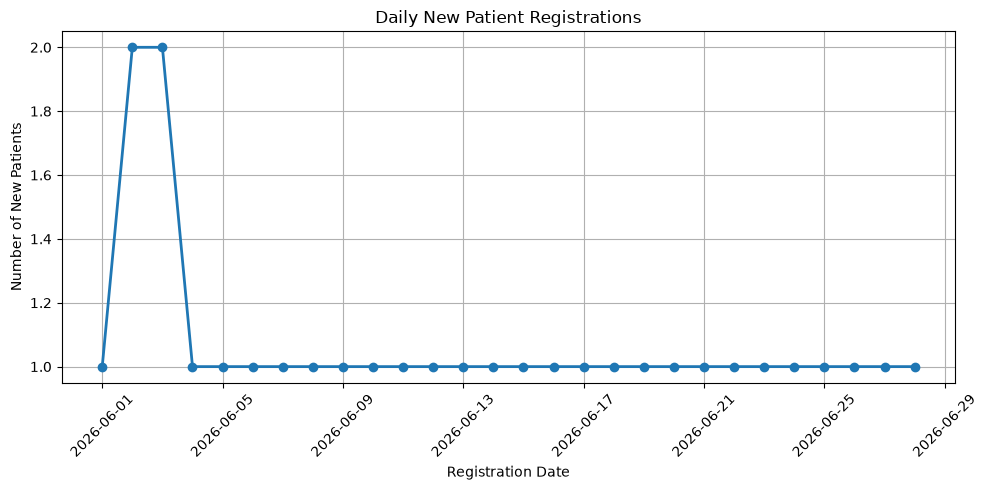

In [25]:
plt.figure(figsize=(10,5))

plt.plot(
    new_patients_daily["registration_date"],
    new_patients_daily["new_patients"],
    marker="o",
    linewidth=2
)

plt.title("Daily New Patient Registrations")

plt.xlabel("Registration Date")

plt.ylabel("Number of New Patients")

plt.xticks(rotation=45)

plt.grid(True)

plt.tight_layout()

plt.show()

In [26]:
appointment_status = (
    appointments_df["appointment_status"]
    .value_counts()
    .reset_index()
)

appointment_status.columns = [
    "Appointment Status",
    "Count"
]

appointment_status

,Appointment Status,Count
0,Completed,35
1,Cancelled,5
2,No Show,5
3,Scheduled,5


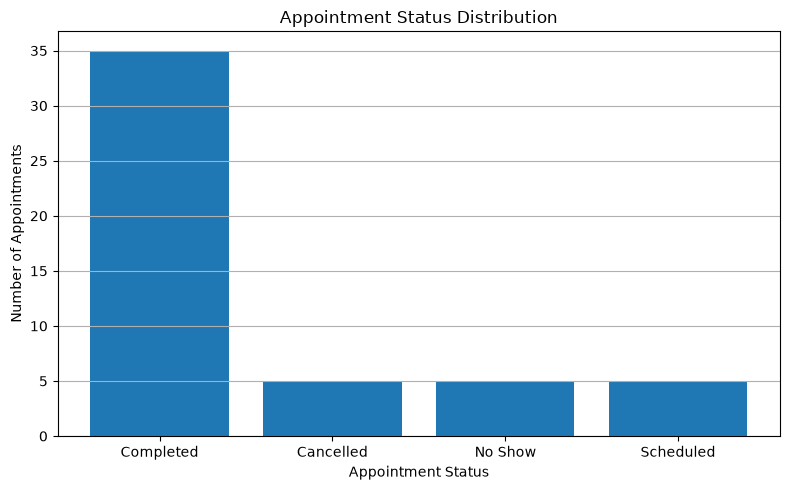

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(
    appointment_status["Appointment Status"],
    appointment_status["Count"]
)

plt.title("Appointment Status Distribution")

plt.xlabel("Appointment Status")

plt.ylabel("Number of Appointments")

plt.grid(axis="y")

plt.tight_layout()

plt.show()

In [30]:
appointment_status_pie = (
    appointments_df["appointment_status"]
    .value_counts()
)

appointment_status_pie

appointment_status
Completed    35
Cancelled     5
No Show       5
Scheduled     5
Name: count, dtype: int64

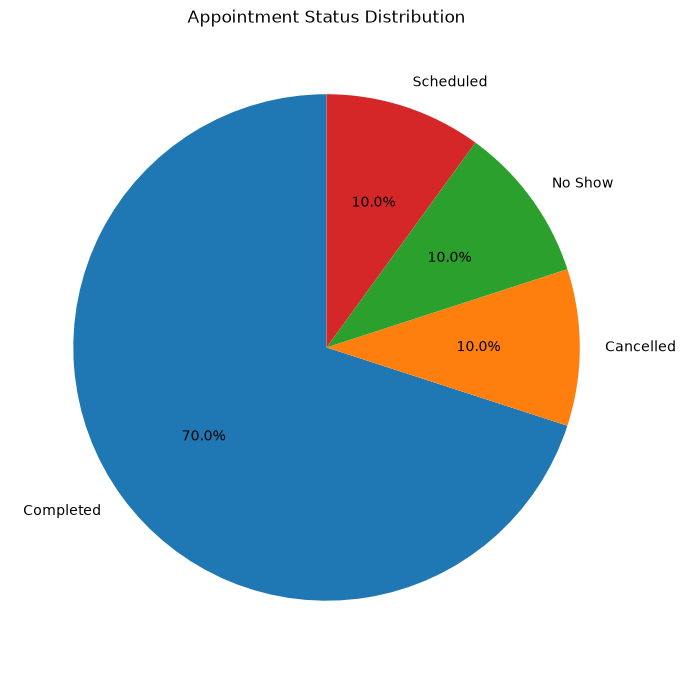

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,7))

plt.pie(
    appointment_status_pie.values,
    labels=appointment_status_pie.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Appointment Status Distribution")

plt.tight_layout()

plt.show()

In [32]:
doctor_appointments


,doctor_id,total_appointments,first_name,last_name,specialization
0,1,5,Arjun,Mehta,Cardiologist
1,2,5,Neha,Kapoor,Cardiologist
2,3,5,Rohan,Iyer,Neurologist
3,4,5,Priya,Nair,Neurologist
4,5,5,Vikram,Singh,Orthopedic
5,6,5,Aisha,Verma,Orthopedic
6,7,5,Karan,Shah,Pediatrician
7,8,5,Sana,Ali,Emergency
8,9,5,Rahul,Joshi,Emergency
9,10,5,Meera,Patel,Emergency


In [33]:
doctor_appointments["Doctor Name"] = (
    doctor_appointments["first_name"] +
    " " +
    doctor_appointments["last_name"]
)

doctor_appointments.head()

,doctor_id,total_appointments,first_name,last_name,specialization,Doctor Name
0,1,5,Arjun,Mehta,Cardiologist,Arjun Mehta
1,2,5,Neha,Kapoor,Cardiologist,Neha Kapoor
2,3,5,Rohan,Iyer,Neurologist,Rohan Iyer
3,4,5,Priya,Nair,Neurologist,Priya Nair
4,5,5,Vikram,Singh,Orthopedic,Vikram Singh


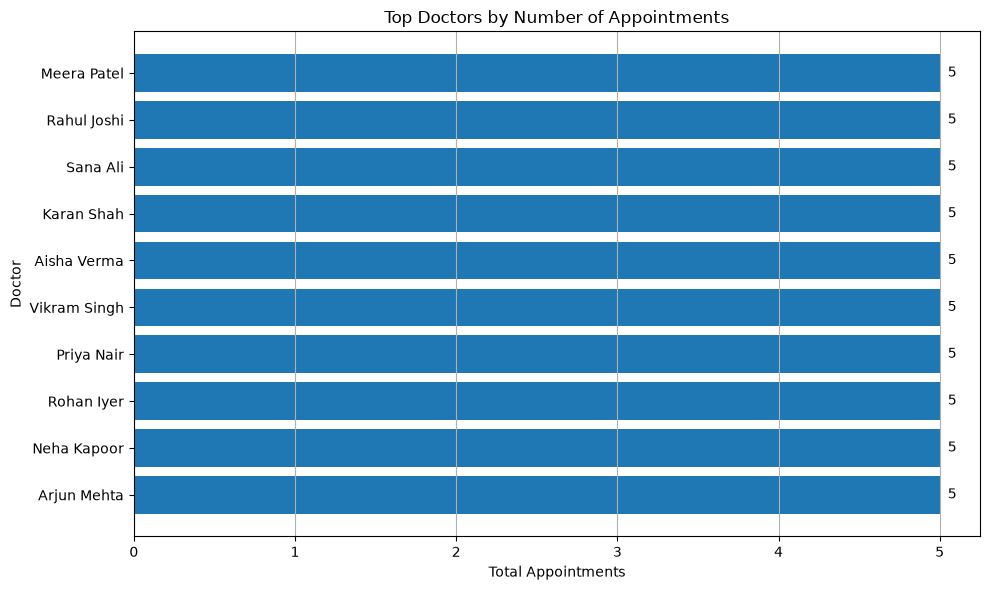

In [34]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

bars = plt.barh(
    doctor_appointments["Doctor Name"],
    doctor_appointments["total_appointments"]
)

for bar in bars:
    width = bar.get_width()

    plt.text(
        width + 0.05,
        bar.get_y() + bar.get_height()/2,
        f"{int(width)}",
        va="center"
    )

plt.title("Top Doctors by Number of Appointments")

plt.xlabel("Total Appointments")

plt.ylabel("Doctor")

plt.grid(axis="x")

plt.tight_layout()

plt.show()

In [35]:
import pandas as pd

revenue_summary = pd.DataFrame({
    "Category": [
        "Total Revenue",
        "Amount Received",
        "Pending Revenue"
    ],
    "Amount": [
        140000,
        134000,
        6000
    ]
})

revenue_summary

,Category,Amount
0,Total Revenue,140000
1,Amount Received,134000
2,Pending Revenue,6000


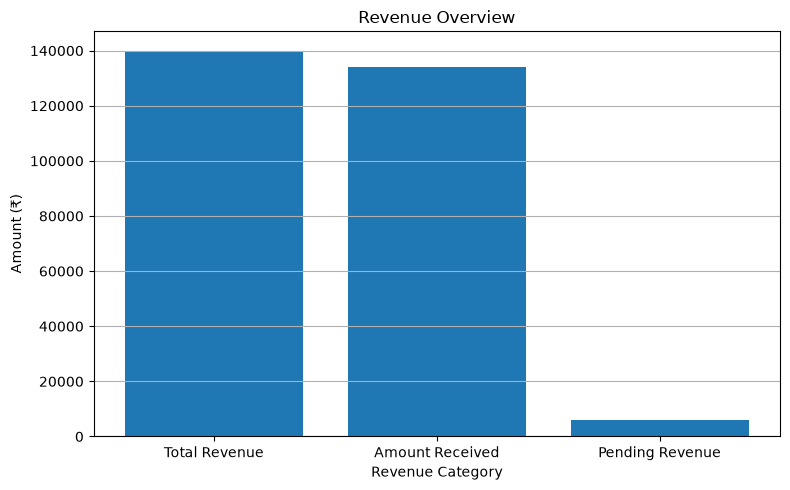

In [36]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

bars = plt.bar(
    revenue_summary["Category"],
    revenue_summary["Amount"]
)

plt.title("Revenue Overview")

plt.xlabel("Revenue Category")

plt.ylabel("Amount (₹)")

plt.grid(axis="y")

plt.tight_layout()

plt.show()

In [37]:
payment_status = (
    payments_df["payment_status"]
    .value_counts()
)

payment_status

payment_status
Paid       32
Pending     3
Name: count, dtype: int64

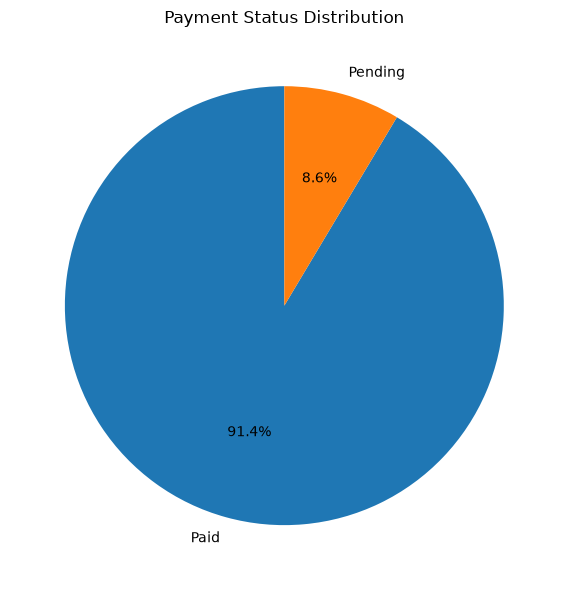

In [38]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))

plt.pie(
    payment_status.values,
    labels=payment_status.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Payment Status Distribution")

plt.tight_layout()

plt.show()

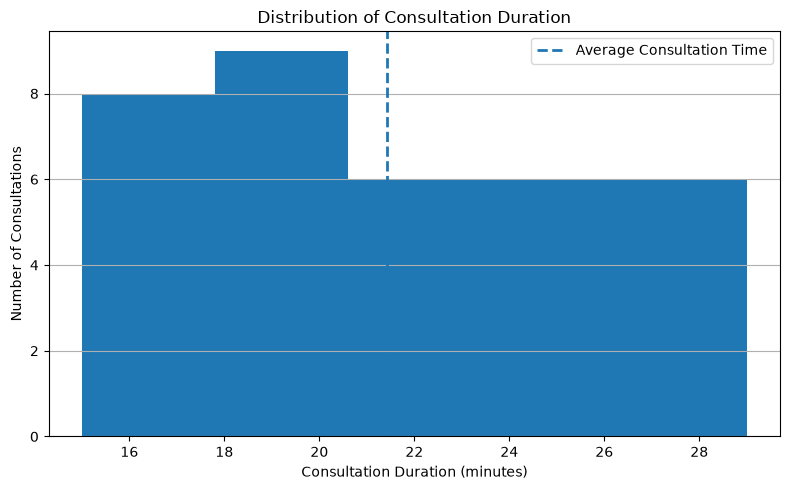

In [40]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(
    encounters_df["consultation_duration"],
    bins=5
)

plt.axvline(
    encounters_df["consultation_duration"].mean(),
    linestyle="--",
    linewidth=2,
    label="Average Consultation Time"
)

plt.title("Distribution of Consultation Duration")

plt.xlabel("Consultation Duration (minutes)")

plt.ylabel("Number of Consultations")

plt.legend()

plt.grid(axis="y")

plt.tight_layout()

plt.show()

In [1]:
import requests

In [2]:
import requests

url = "https://jsonplaceholder.typicode.com/users"

response = requests.get(url)

print(response.status_code)

200


In [3]:
data = response.json()

print(data)

[{'id': 1, 'name': 'Leanne Graham', 'username': 'Bret', 'email': 'Sincere@april.biz', 'address': {'street': 'Kulas Light', 'suite': 'Apt. 556', 'city': 'Gwenborough', 'zipcode': '92998-3874', 'geo': {'lat': '-37.3159', 'lng': '81.1496'}}, 'phone': '1-770-736-8031 x56442', 'website': 'hildegard.org', 'company': {'name': 'Romaguera-Crona', 'catchPhrase': 'Multi-layered client-server neural-net', 'bs': 'harness real-time e-markets'}}, {'id': 2, 'name': 'Ervin Howell', 'username': 'Antonette', 'email': 'Shanna@melissa.tv', 'address': {'street': 'Victor Plains', 'suite': 'Suite 879', 'city': 'Wisokyburgh', 'zipcode': '90566-7771', 'geo': {'lat': '-43.9509', 'lng': '-34.4618'}}, 'phone': '010-692-6593 x09125', 'website': 'anastasia.net', 'company': {'name': 'Deckow-Crist', 'catchPhrase': 'Proactive didactic contingency', 'bs': 'synergize scalable supply-chains'}}, {'id': 3, 'name': 'Clementine Bauch', 'username': 'Samantha', 'email': 'Nathan@yesenia.net', 'address': {'street': 'Douglas Exten

In [4]:
type(data)

list

In [5]:
data[0]

{'id': 1,
 'name': 'Leanne Graham',
 'username': 'Bret',
 'email': 'Sincere@april.biz',
 'address': {'street': 'Kulas Light',
  'suite': 'Apt. 556',
  'city': 'Gwenborough',
  'zipcode': '92998-3874',
  'geo': {'lat': '-37.3159', 'lng': '81.1496'}},
 'phone': '1-770-736-8031 x56442',
 'website': 'hildegard.org',
 'company': {'name': 'Romaguera-Crona',
  'catchPhrase': 'Multi-layered client-server neural-net',
  'bs': 'harness real-time e-markets'}}

In [6]:
type(data[0])

dict

In [7]:
import pandas as pd
api_df = pd.DataFrame(data)
api_df.head()

,id,name,username,email,address,phone,website,company
0,1,Leanne Graham,Bret,Sincere@april.biz,"{'street': 'Kulas Light', 'suite': 'Apt. 556',...",1-770-736-8031 x56442,hildegard.org,"{'name': 'Romaguera-Crona', 'catchPhrase': 'Mu..."
1,2,Ervin Howell,Antonette,Shanna@melissa.tv,"{'street': 'Victor Plains', 'suite': 'Suite 87...",010-692-6593 x09125,anastasia.net,"{'name': 'Deckow-Crist', 'catchPhrase': 'Proac..."
2,3,Clementine Bauch,Samantha,Nathan@yesenia.net,"{'street': 'Douglas Extension', 'suite': 'Suit...",1-463-123-4447,ramiro.info,"{'name': 'Romaguera-Jacobson', 'catchPhrase': ..."
3,4,Patricia Lebsack,Karianne,Julianne.OConner@kory.org,"{'street': 'Hoeger Mall', 'suite': 'Apt. 692',...",493-170-9623 x156,kale.biz,"{'name': 'Robel-Corkery', 'catchPhrase': 'Mult..."
4,5,Chelsey Dietrich,Kamren,Lucio_Hettinger@annie.ca,"{'street': 'Skiles Walks', 'suite': 'Suite 351...",(254)954-1289,demarco.info,"{'name': 'Keebler LLC', 'catchPhrase': 'User-c..."


In [8]:
api_df.shape

(10, 8)

In [9]:
api_df.columns


Index(['id', 'name', 'username', 'email', 'address', 'phone', 'website',
       'company'],
      dtype='str')

In [10]:
api_df.dtypes

id           int64
name           str
username       str
email          str
address     object
phone          str
website        str
company     object
dtype: object

In [11]:
api_df.isnull().sum()

id          0
name        0
username    0
email       0
address     0
phone       0
website     0
company     0
dtype: int64

In [12]:
api_users = api_df[
    [
        "id",
        "name",
        "username",
        "email",
        "phone",
        "website"
    ]
]

api_users.head()

,id,name,username,email,phone,website
0,1,Leanne Graham,Bret,Sincere@april.biz,1-770-736-8031 x56442,hildegard.org
1,2,Ervin Howell,Antonette,Shanna@melissa.tv,010-692-6593 x09125,anastasia.net
2,3,Clementine Bauch,Samantha,Nathan@yesenia.net,1-463-123-4447,ramiro.info
3,4,Patricia Lebsack,Karianne,Julianne.OConner@kory.org,493-170-9623 x156,kale.biz
4,5,Chelsey Dietrich,Kamren,Lucio_Hettinger@annie.ca,(254)954-1289,demarco.info


In [14]:
api_users.to_csv(
    "api_users.csv",
    index=False
)

In [1]:
dashboard_df = appointments_df.merge(
    patients_df[
        [
            "patient_id",
            "first_name",
            "last_name",
            "gender",
            "blood_group",
            "registration_date"
        ]
    ],
    on="patient_id",
    how="left"
)

dashboard_df.head()

NameError: name 'appointments_df' is not defined